In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import joblib

In [2]:
# only needs to be run once to give colab permission to access google drive
# This is to avoid needing to re-upload the 550 MB .csv every time

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#You might need to adjust the filepath for this, I haven't tested running it from another google account. I think since it's a shared folder is should still work?
path = "/content/drive/MyDrive/DATA-433 Group Project/Traffic_Crashes_-_Crashes.csv"

df = pd.read_csv(path)

In [4]:
df.columns = df.columns.str.strip()

print(df.shape)
print(df.columns[:10])

(1031725, 48)
Index(['CRASH_RECORD_ID', 'CRASH_DATE_EST_I', 'CRASH_DATE',
       'POSTED_SPEED_LIMIT', 'TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION',
       'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE',
       'TRAFFICWAY_TYPE'],
      dtype='object')


In [5]:
df["target"] = df["MOST_SEVERE_INJURY"].apply(
    lambda x: 0 if x == "NO INDICATION OF INJURY" else 1
)

In [6]:
# --- DROP LEAKAGE + USELESS COLUMNS---
drop_cols = [
    "MOST_SEVERE_INJURY",
    "INJURIES_TOTAL",
    "INJURIES_FATAL",
    "INJURIES_INCAPACITATING",
    "INJURIES_NON_INCAPACITATING",
    "INJURIES_REPORTED_NOT_EVIDENT",
    "INJURIES_NO_INDICATION",
    "INJURIES_UNKNOWN",
    "CRASH_RECORD_ID",
    "LOCATION",
    "DATE_POLICE_NOTIFIED",
    "REPORT_TYPE",
    "CRASH_TYPE",
    "CRASH_DATE"
]

df = df.drop(columns=drop_cols, errors="ignore")

In [7]:
# --- ENCODE ---
encoders = {}
for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [8]:
# --- FILL NA ---
df = df.fillna(-1)

# --- SPLIT ---
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# --- MODEL --- (this takes a while, 4 minutes when I last ran it)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
# --- EVAL ---
preds = model.predict(X_test)

print("=== Classification Report ===")
print(classification_report(y_test, preds))

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.89      0.99      0.93    176424
           1       0.75      0.26      0.39     29921

    accuracy                           0.88    206345
   macro avg       0.82      0.62      0.66    206345
weighted avg       0.87      0.88      0.86    206345



In [11]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
print(feat_imp.sort_values(ascending=False).head(10))

FIRST_CRASH_TYPE           0.135779
LATITUDE                   0.079210
LONGITUDE                  0.079115
STREET_NO                  0.076422
BEAT_OF_OCCURRENCE         0.063954
STREET_NAME                0.063307
CRASH_HOUR                 0.056835
CRASH_MONTH                0.049060
PRIM_CONTRIBUTORY_CAUSE    0.047249
CRASH_DAY_OF_WEEK          0.040528
dtype: float64


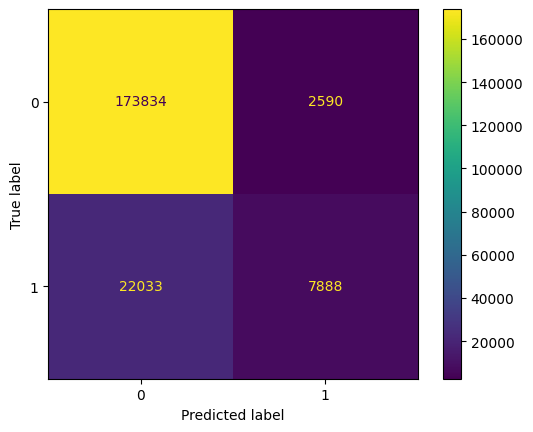

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [15]:
import joblib

joblib.dump(model, "crash_model.pkl")
joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']

In [16]:
from google.colab import files
files.download("crash_model.pkl")
files.download("encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>